Import Library

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img

Drive Mounting

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Data Directory

In [ ]:
#name of the directories
os.listdir("/content/drive/MyDrive/BDML Dataset/SheepFaceImages")

['Poll Dorset', 'White Suffolk', 'Suffolk', 'Marino']

In [ ]:
data_dir = "/content/drive/MyDrive/BDML Dataset/SheepFaceImages"

Marino = '/content/drive/MyDrive/BDML Dataset/SheepFaceImages/Marino'
WhiteSuffolk = '/content/drive/MyDrive/BDML Dataset/SheepFaceImages/White Suffolk'
Suffolk = '/content/drive/MyDrive/BDML Dataset/SheepFaceImages/Suffolk'
PollDorset = '/content/drive/MyDrive/BDML Dataset/SheepFaceImages/Poll Dorset'

train_images = data_dir


Creating Dataset

In [ ]:
from tqdm import tqdm
x = []
y = []

def create_dataset(dirname,breedname):
    for i in tqdm(os.listdir(dirname)):
        path = os.path.join(dirname,i)
        try:
            img = cv2.imread(path)
            img = cv2.resize(img,(150,150))
        except:
            continue

        x.append(img)
        y.append(breedname)
    return x,y

In [ ]:
x,y = create_dataset(Marino,"Marino")
x,y = create_dataset(WhiteSuffolk,"White Suffolk")
x,y = create_dataset(PollDorset,"Poll Dorset")
x,y = create_dataset(Suffolk,"Suffolk")

In [ ]:
x = np.array(x)
y = np.array(y)
print(x.shape,y.shape)

In [ ]:
def show_example(img, label):
  print('Label: ', train_dataset.classes[label], "("+str(label)+")")
  plt.imshow(img.permute(1, 2, 0))


Showing Images

In [ ]:
plt.figure(figsize = (12,7))
for i in range(10):
    indx = random.randint(0,len(y))
    img = x[indx]
    plt.subplot(2,5,i+1)
    plt.subplots_adjust(hspace=0.3)
    plt.imshow(img)
    plt.xlabel(y[indx])

plt.tight_layout()
plt.show()

In [ ]:
plt.style.use("ggplot")
plt.figure(figsize=(9,6))
sns.countplot(y)
plt.show()

Dividing Dataset

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y)

In [ ]:
#divide our dataset into train & test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [ ]:
img_size=150
x_train = np.array(x_train)/255.0
x_test = np.array(x_test)/255.0

x_train = x_train.reshape(-1,img_size,img_size,3)
y_train = np.array(y_train)

x_test = x_test.reshape(-1,img_size,img_size,3)
y_test = np.array(y_test)

Model Resnet50

In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50
resnet = ResNet50(weights = "imagenet",include_top = False,input_shape=(150,150,3))

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten,Dense,Dropout

model = Sequential()
model.add(resnet)
model.add(Flatten())
model.add(Dense(4,activation = "softmax"))

model.summary()

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
checkpoint = ModelCheckpoint("resnet50.h5",monitor = "val_accuracy",save_best_only = True,verbose=1)
earlystop = EarlyStopping(monitor="val_accuracy",patience=8,verbose=1)

model.compile(optimizer="adam",loss = "categorical_crossentropy",metrics = ["accuracy"])

In [ ]:
history = model.fit(x_train,y_train,batch_size=32,validation_data = (x_test,y_test),
                    epochs=20,verbose=1,callbacks = [checkpoint,earlystop])


In [ ]:
loss,accuracy = model.evaluate(x_test,y_test)
print(f"Loss for resnet50: {loss}")
print(f"Accuracy for resnet50: {accuracy}")

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
y_pred = model.predict_classes(x_test)
y_pred[:15]

In [ ]:
y_test_resnet = np.argmax(y_test,axis=1)
y_test_resnet[:15]

In [ ]:
print(classification_report(y_test_resnet,y_pred))

Model VGG16

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

vgg16 = VGG16(weights = "imagenet", include_top = False, input_shape=(150, 150, 3))


In [ ]:
for layer in vgg16.layers:
  layer.trainable = False

In [ ]:
model2 = model2 = Sequential()
model2.add(vgg16)
model2.add(Flatten())
model2.add(Dense(4,activation = "softmax"))

model2.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg16 (Functional)           (None, 4, 4, 512)         14714688  
_________________________________________________________________
flatten_2 (Flatten)          (None, 8192)              0         
_________________________________________________________________
dense_2 (Dense)              (None, 4)                 32772     
Total params: 14,747,460
Trainable params: 32,772
Non-trainable params: 14,714,688
_________________________________________________________________


In [ ]:
checkpoint2 = ModelCheckpoint("vgg16.h5",monitor = "val_accuracy",save_best_only = True,verbose=1)
earlystop2 = EarlyStopping(monitor="val_accuracy",patience=8,verbose=1)
model2.compile(optimizer="adam",loss = "categorical_crossentropy",metrics = ["accuracy"])

history2 = model2.fit(x_train,y_train,batch_size=32,validation_data = (x_test,y_test),
                    epochs=20,verbose=1,callbacks = [checkpoint2,earlystop2])

Epoch 1/20
42/42 [==============================] - 4s 93ms/step - loss: 1.2256 - accuracy: 0.4341 - val_loss: 0.6221 - val_accuracy: 0.7917

Epoch 00001: val_accuracy improved from -inf to 0.79167, saving model to vgg16.h5
Epoch 2/20
42/42 [==============================] - 4s 90ms/step - loss: 0.5185 - accuracy: 0.8570 - val_loss: 0.4601 - val_accuracy: 0.8542

Epoch 00002: val_accuracy improved from 0.79167 to 0.85417, saving model to vgg16.h5
Epoch 3/20
42/42 [==============================] - 4s 91ms/step - loss: 0.3761 - accuracy: 0.9259 - val_loss: 0.3803 - val_accuracy: 0.8839

Epoch 00003: val_accuracy improved from 0.85417 to 0.88393, saving model to vgg16.h5
Epoch 4/20
42/42 [==============================] - 4s 93ms/step - loss: 0.2903 - accuracy: 0.9374 - val_loss: 0.3342 - val_accuracy: 0.9048

Epoch 00004: val_accuracy improved from 0.88393 to 0.90476, saving model to vgg16.h5
Epoch 5/20
42/42 [==============================] - 4s 94ms/step - loss: 0.2373 - accuracy: 0.9

In [ ]:
loss2,accuracy2 = model2.evaluate(x_test,y_test)
print(f"Loss for vgg16: {loss2}")
print(f"Accuracy for vgg16: {accuracy2}")

11/11 [==============================] - 1s 66ms/step - loss: 0.1723 - accuracy: 0.9435
Loss for vgg16: 0.17229261994361877
Accuracy for vgg16: 0.9434523582458496


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
y_pred = model2.predict_classes(x_test)
y_pred[:15]

/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/engine/sequential.py:450: UserWarning: `model.predict_classes()` is deprecated and will be removed after 2021-01-01. Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).
  warnings.warn('`model.predict_classes()` is deprecated and '


array([1, 2, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 0, 3, 1])

In [ ]:
y_test_vgg16 = np.argmax(y_test,axis=1)
y_test_vgg16[:15]

array([1, 2, 3, 3, 3, 0, 3, 3, 3, 2, 3, 2, 0, 3, 1])

In [ ]:
print(classification_report(y_test_vgg16,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93        82
           1       0.93      0.93      0.93        95
           2       0.97      0.96      0.97        74
           3       0.92      0.99      0.95        85

    accuracy                           0.94       336
   macro avg       0.95      0.94      0.94       336
weighted avg       0.94      0.94      0.94       336



Plotting Learning Curve

In [ ]:
def plot_learning_curve_for_resnet(history,epochs):
    plt.style.use("ggplot")
    plt.figure(figsize=(12,6))
    epochs = np.arange(1,epochs+1)
    plt.subplot(2,2,1)
    plt.plot(epochs,history.history["accuracy"],"go-")
    plt.plot(epochs,history.history["val_accuracy"],"ro-")
    plt.title("Model Accuracy Curve for ResNet50")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(["Train","Val"],loc = "upper left")

    plt.subplot(2,2,2)
    plt.plot(epochs,history.history["loss"],"go-")
    plt.plot(epochs,history.history["val_loss"],"ro-")
    plt.title("Model Loss Curve for ResNet50")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(["Train","Val"],loc = "upper left")

    plt.show()

In [ ]:
def plot_learning_curve_for_vgg16(history,epochs):
    plt.style.use("ggplot")
    plt.figure(figsize=(12,6))
    epochs = np.arange(1,epochs+1)
    plt.subplot(1,2,1)
    plt.plot(epochs,history.history["accuracy"],"go-")
    plt.plot(epochs,history.history["val_accuracy"],"ro-")
    plt.title("Model Accuracy Curve for VGG16")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(["Train","Val"],loc = "upper left")

    plt.subplot(1,2,2)
    plt.plot(epochs,history.history["loss"],"go-")
    plt.plot(epochs,history.history["val_loss"],"ro-")
    plt.title("Model Loss Curve for VGG16")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(["Train","Val"],loc = "upper left")
    plt.show()

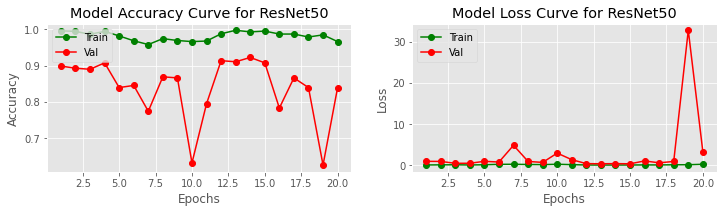

In [ ]:
plot_learning_curve_for_resnet(history,20)

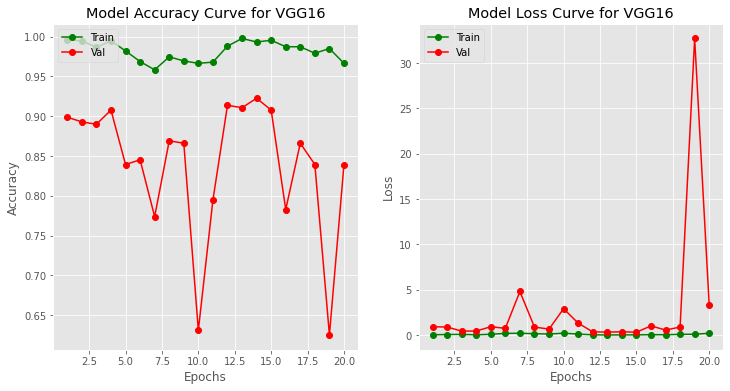

In [ ]:
plot_learning_curve_for_vgg16(history,20)

Checking Models Performance

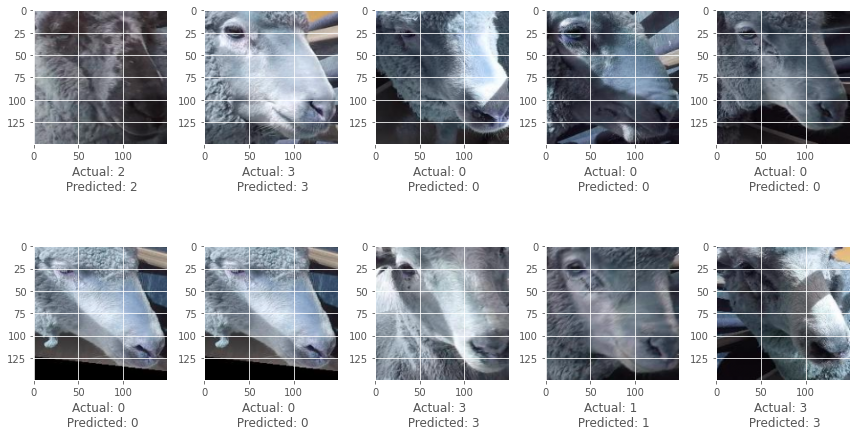

In [ ]:
plt.figure(figsize=(12,7))
for i in range(10):
    indx = random.randint(0,len(y_test_resnet))
    plt.subplot(2,5,i+1)
    plt.subplots_adjust(hspace=0.3)
    plt.imshow(x_test[indx])
    plt.xlabel(f"Actual: {y_test_resnet[indx]} \n Predicted: {y_pred[indx]}")

plt.tight_layout()
plt.show()


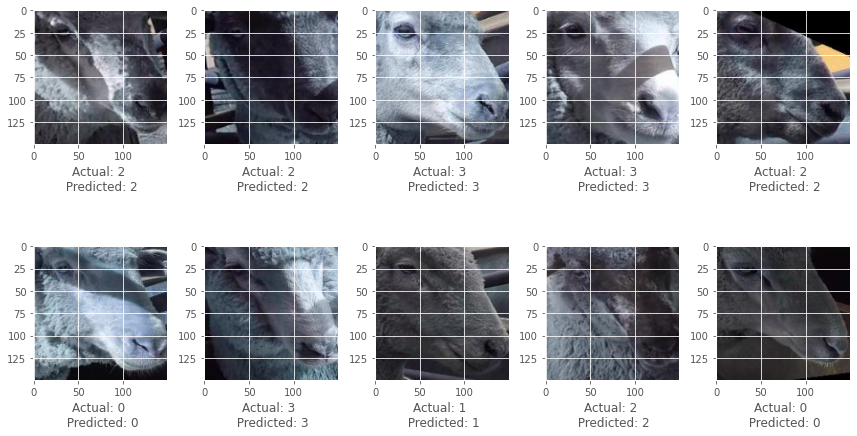

In [ ]:
plt.figure(figsize=(12,7))
for i in range(10):
    indx = random.randint(0,len(y_test_vgg16))
    plt.subplot(2,5,i+1)
    plt.subplots_adjust(hspace=0.3)
    plt.imshow(x_test[indx])
    plt.xlabel(f"Actual: {y_test_vgg16[indx]} \n Predicted: {y_pred[indx]}")

plt.tight_layout()
plt.show()
